*Name* : **Abhi Mondal**    
*Roll No.*: **22MS075**

# Moran Process with constant selection but without mutation

In [41]:
# pakages
import numpy as np
import matplotlib.pyplot as plt
from numba import njit              # used for fast compilation (for install run "pip install numba")

## Part I

In [42]:
# parameter
N = 100         # population size
fit_0 = 1.01    # fitness of type 0
fit_1 = 1       # fitness of type  1
N_T = 1000      # number of trials

In [43]:
@njit
# function to perform the Moran Process
# input : (population size, fitness of type 0, fitness of type 1, population size of type 0)
# output: (frequency of type 0, frequecny of type 1)

def Moran_selec_traj(N,fit_0,fit_1,pop_0):
    norm_fit_0 = fit_0/(fit_0 + fit_1)              # normalized fitness for type 0
    norm_fit_1 = fit_1/(fit_0 + fit_1)              # normalized fitness for type 1

    population = np.array([0]*(pop_0) + [1]*(N-pop_0))      # initial population with 1 type 0 and N - 1 type 1
    np.random.shuffle(population)                   # shuffle the population

    t = 0                                           # index
    freq_1 = []                                     # frequecy matrix for type 1 
    while np.any(population == 0) and np.any(population == 1):
        freq_1.append(np.mean(population == 1))     # record the frequency of type 1 ; freq of 0 will be 1 - freq_1    
    
        parent_index = np.random.randint(N)         # randomly select an index for parent
        parent_type = population[parent_index]      # check the parent type
    
        r = np.random.rand()                        # random number to deal with the probability of reproduction based on the fitness


        if parent_type == 0 and r > norm_fit_0:     # reproduction not possible for type 0 
            continue  
        if parent_type == 1 and r > norm_fit_1:     # reproduction not possible for type 1
            continue  
                                                    # other wise selected for reproduction

        death_index = np.random.randint(N)          # death index selection 
    
        population[death_index] = parent_type       # death individual is replaced by the new ofspring
    
        t += 1                                      # next generation
    
    freq_1.append(np.mean(population == 1))         # append the last frequency
    freq_0 = 1 - np.array(freq_1)                   # frequency of type 0 = 1 - frequency of type 
    
    return freq_0, np.array(freq_1)



In [44]:
@njit
# function to perform the Moran Process
# input : (population size,  population size of type 0, fitness of type 0, fitness of type 1, number of trials)
# output: [fixation probability of type 0, fixation probability of type 1]

def Moran_selec(N,pop_0,fit_0,fit_1,N_trial):
    norm_fit_0 = fit_0/(fit_0 + fit_1)                  # normalized fitness for type 0
    norm_fit_1 = fit_1/(fit_0 + fit_1)                  # normalized fitness for type 1

    fixed_0 = np.zeros(N_trial)                         # fixation matrix for type 0 [1 if yes 0 if no]

    for i in range(N_trial):                            # for N tirals
        population = np.array([0]*(pop_0) + [1]*(N-pop_0))      # initial population with 1 type 0 and N - 1 type 1
        np.random.shuffle(population)                   # shuffle the population

        t = 0                                           # index
        while np.any(population == 0) and np.any(population == 1):
        
            parent_index = np.random.randint(N)         # randomly select an index for parent
            parent_type = population[parent_index]      # check the parent type
        
            r = np.random.rand()                        # random number to deal with the probability of reproduction based on the fitness


            if parent_type == 0 and r > norm_fit_0:     # reproduction not possible for type 0 
                continue  
            if parent_type == 1 and r > norm_fit_1:     # reproduction not possible for type 1
                continue  
                                                        # other wise selected for reproduction

            death_index = np.random.randint(N)          # death index selection 
        
            population[death_index] = parent_type       # death individual is replaced by the new ofspring
        
            t += 1                                      # next generation
        
        freq_0 = np.mean(population == 0)               # final frequency of 0 
        fixed_0[i] = freq_0                             # in binary 

    fix_0_prob = np.mean(fixed_0 == 1)                  # fixation probability of type 0
    fix_1_prob = np.mean(fixed_0 == 0)                  # fixation probability of type 1

    return fix_0_prob,fix_1_prob

In [45]:
freq_0,freq_1 = Moran_selec_traj(N,fit_0,fit_1,pop_0=1)

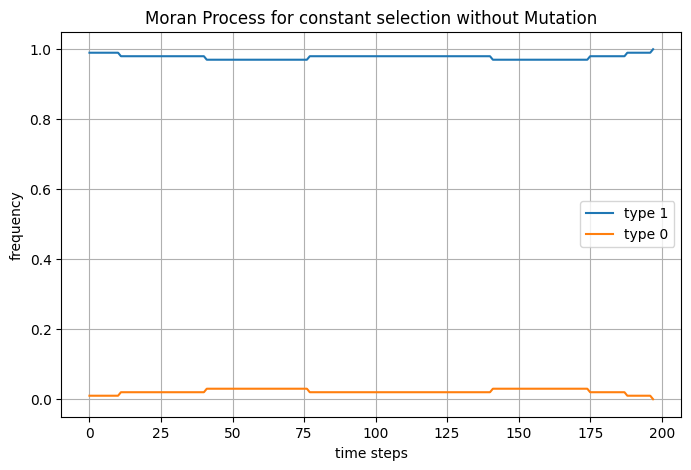

In [46]:
# plotting 

plt.figure(figsize=(8,5))
plt.plot(freq_1, label="type 1")
plt.plot(freq_0, label="type 0")
plt.xlabel("time steps")
plt.ylabel("frequency")
plt.title("Moran Process for constant selection without Mutation")
plt.legend(loc = "best")
plt.grid(True)
plt.show()

In [50]:
fixed_0,fixed_1 = Moran_selec(N,1,fit_0,fit_1,N_T)

In [ ]:
theorical_fixed_0 = (1 - 1/fit_0)/(1 - 1/(fit_0**N))
perr_err = (abs(theorical_fixed_0 - fixed_0)/theorical_fixed_0)*100

In [52]:
print(f"Theoretical value of fixation probability of type 0 for population size {N} is {theorical_fixed_0: .3f}")
print(f"From the simulation, fixation probability of type 0 is {fixed_0: .3f}, fixation probability of type 1 is {fixed_1: .3f}")
print(f"Error in probability is {perr_err: .2f}%")


Theoretical value of fixation probability of type 0 for population size 100 is  0.016
From the simulation, fixation probability of type 0 is  0.017, fixation probability of type 1 is  0.983
Error in probability is  8.22%


## Part II

In [53]:
# parameter
N = 100         # population size
fit_0 = 0.99    # fitness of type 0
fit_1 = 1       # fitness of type  1
N_T = 1000      # number of trials

In [54]:
freq_0,freq_1 = Moran_selec_traj(N,fit_0,fit_1,pop_0=(N//2))

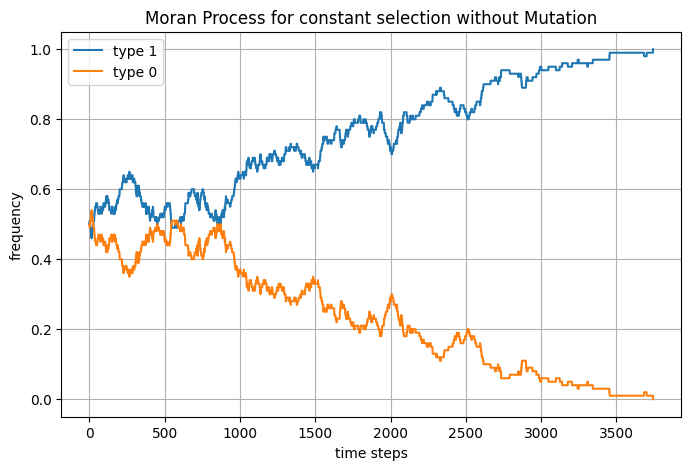

In [55]:
# plotting 

plt.figure(figsize=(8,5))
plt.plot(freq_1, label="type 1")
plt.plot(freq_0, label="type 0")
plt.xlabel("time steps")
plt.ylabel("frequency")
plt.title("Moran Process for constant selection without Mutation")
plt.legend(loc = "best")
plt.grid(True)
plt.show()

In [57]:
fixed_0,fixed_1 = Moran_selec(N,(N//2),fit_0,fit_1,N_T)

In [58]:
theorical_fixed_0 = (1 - 1/(fit_0**(N//2)))/(1 - 1/(fit_0**N))
perr_err = (abs(theorical_fixed_0 - fixed_0)/theorical_fixed_0)*100

In [59]:
print(f"Theoretical value of fixation probability of type 0 for population size {N} is {theorical_fixed_0: .3f}")
print(f"From the simulation, fixation probability of type 0 is {fixed_0: .3f}, fixation probability of type 1 is {fixed_1: .3f}")
print(f"Error in probability is {perr_err: .2f}%")


Theoretical value of fixation probability of type 0 for population size 100 is  0.377
From the simulation, fixation probability of type 0 is  0.367, fixation probability of type 1 is  0.633
Error in probability is  2.64%
